# Tecnica de estandarizacion y PCA
## 1. Carga de la Base de Datos Enriquecida

En este tercer notebook, comenzamos importando nuestra matriz de características ya procesada, la cual contiene las 16 métricas de scouting P90 ajustadas y la información categórica de cada jugador (Liga, Equipo y Posición).

In [9]:
import pandas as pd
from IPython.display import display

# 1. Cargar la base de datos enriquecida
ruta_archivo = '/content/drive/MyDrive/dataset_perfiles_jugadores_1516.csv'
df = pd.read_csv(ruta_archivo)

# Verificamos que la base esté lista y tenga las nuevas columnas
print("="*60)
print(f"✅ Base cargada: {df.shape[0]} jugadores y {df.shape[1]} columnas.")
print("="*60)
display(df.head())

✅ Base cargada: 1699 jugadores y 27 columnas.


,player,team,competition_name,position_group,position_detail,minutos_jugados,xG P90,xG por Tiro,Asistencias a Tiro P90,% Centralidad Equipo,...,Recup. Último Tercio P90,Conducciones Progresivas P90,Influencia Global P90,Faltas Recibidas P90,Pérdidas de Balón P90,value_eur,wage_eur,age,weight_kg,height_cm
0,Aaron Cresswell,West Ham United,Premier League,Defensa,Left Back,3398,0.021197,0.029640,1.085933,11.456168,...,0.979988,2.834020,147.872278,0.927016,1.430253,3000000.0,35000.0,25.0,66.0,170.0
1,Aaron Lennon,Everton,Premier League,Delantero,Right Wing,2130,0.082510,0.108485,0.887324,2.772703,...,1.225352,2.915493,98.704225,1.098592,1.732394,625000.0,8000.0,29.0,74.0,180.0
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista,Left Defensive Midfield,2826,0.234788,0.110035,1.082803,9.927251,...,2.229299,5.477707,256.401274,1.815287,3.949045,26000000.0,130000.0,24.0,70.0,177.0
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista,Left Center Midfield,1902,0.038600,0.407878,0.473186,4.092397,...,0.283912,0.899054,34.826498,0.283912,0.567823,4300000.0,60000.0,26.0,73.0,179.0
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista,Center Attacking Midfield,1902,0.133185,0.117276,2.176656,5.601139,...,1.135647,3.264984,131.072555,1.041009,1.561514,4300000.0,60000.0,26.0,73.0,179.0


## 2. Limpieza de Datos y Filtro de Multicolinealidad

Antes de estandarizar y aplicar el Análisis de Componentes Principales (PCA), debemos asegurar que nuestro modelo no sufra de "secuestro de varianza" ni de errores matemáticos. Si introducimos variables que miden prácticamente lo mismo (correlación > 0.85 o 0.90), el PCA le dará un peso desproporcionado a ese rasgo táctico.

Utilizando los hallazgos de nuestra estadística descriptiva y la matriz de correlación como **filtro cuantitativo**, hemos depurado el ecosistema eliminando una sola métrica problemática:

1. **Duelos Aéreos Ganados P90 (Varianza Cero):** Como detectamos en la fase de EDA, esta variable arrojó valores de 0 absoluto para toda la población estadística (debido a la falta de registro o nomenclatura distinta en la temporada 15/16). Mantenerla colapsaría la estandarización posterior (generando un error de división por cero al aplicar el Z-Score) y no aporta varianza al modelo.

Ninguna otra variable será eliminada del análisis. Tras realizar el análisis de correlación, la relación más alta encontrada es la de `Pases al Último Tercio` con `Asistencias a Tiro`, que alcanza un coeficiente de `0.8`, seguida por la dupla de `Pérdidas de Balón` con `Recuperaciones en el Último Tercio` con un `0.79`. El resto de las combinaciones no supera el umbral de `0.77`, lo que garantiza que las dimensiones restantes son independientes, conservan una riqueza táctica óptima y no presentan problemas severos de multicolinealidad.

✅ Base cargada: 1699 jugadores y 27 columnas.


,player,team,competition_name,position_group
0,Aaron Cresswell,West Ham United,Premier League,Defensa
1,Aaron Lennon,Everton,Premier League,Delantero
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista



 🔍 DETECCIÓN AUTOMÁTICA DE MULTICOLINEALIDAD (PRE-PCA)
⚠️ Pares de variables con correlación superior a 0.85:

✅ Excelente: No hay variables altamente redundantes. Vía libre para usar todas.



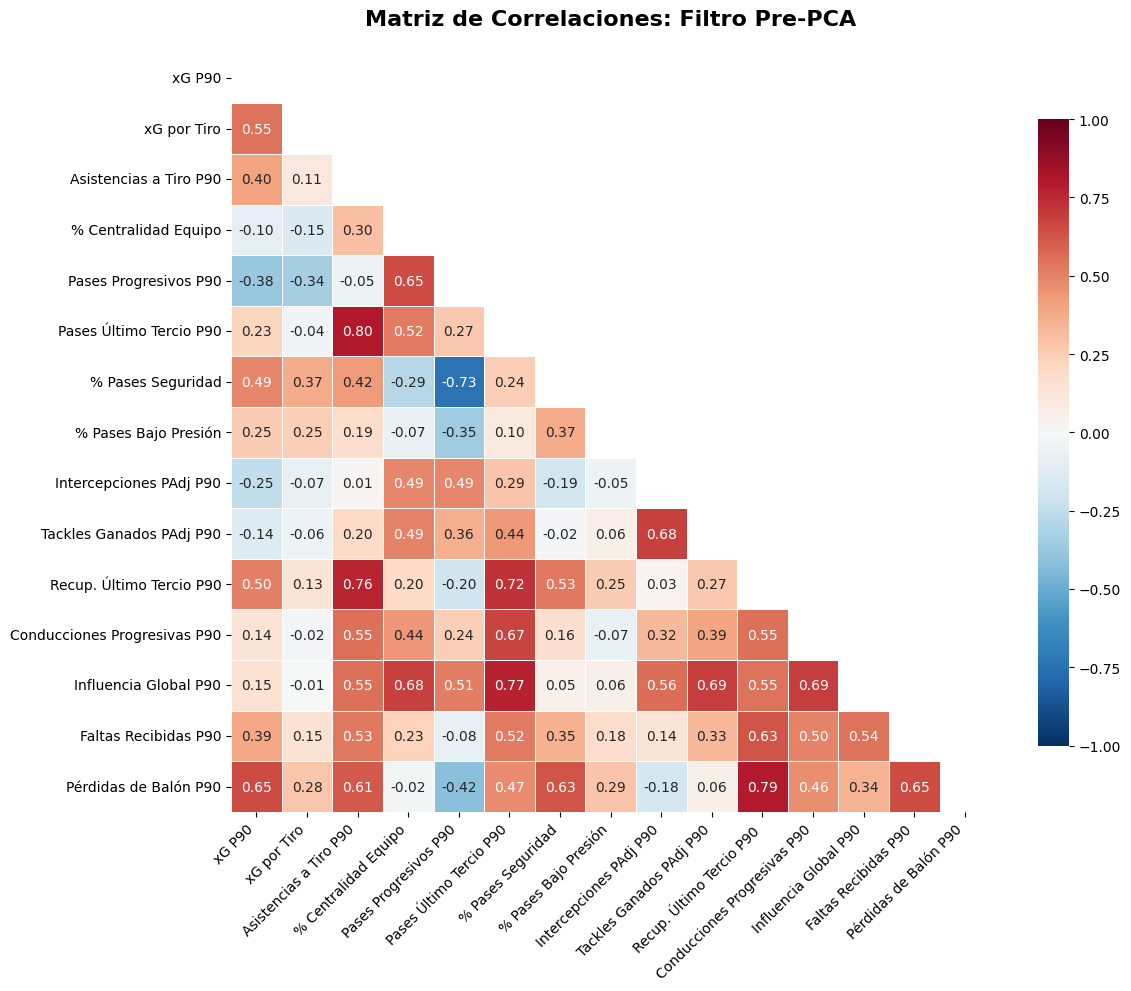

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ==============================================================================
# 1. CARGA DE BASE DE DATOS
# ==============================================================================
ruta_archivo = '/content/drive/MyDrive/dataset_perfiles_jugadores_1516.csv'
df = pd.read_csv(ruta_archivo)

# Verificamos que la base esté lista y tenga las nuevas columnas
print("="*60)
print(f"✅ Base cargada: {df.shape[0]} jugadores y {df.shape[1]} columnas.")
print("="*60)
display(df[['player', 'team', 'competition_name', 'position_group']].head())

# ==============================================================================
# 2. DEFINICIÓN DE MÉTRICAS TÁCTICAS
# ==============================================================================
columnas_modelo = [
    'xG P90', 'xG por Tiro', 'Asistencias a Tiro P90',
    '% Centralidad Equipo', 'Pases Progresivos P90', 'Pases Último Tercio P90',
    '% Pases Seguridad', '% Pases Bajo Presión',
    'Intercepciones PAdj P90', 'Tackles Ganados PAdj P90',
    'Recup. Último Tercio P90',
    'Conducciones Progresivas P90', 'Influencia Global P90',
    'Faltas Recibidas P90', 'Pérdidas de Balón P90'
]

# ==============================================================================
# 3. DETECCIÓN AUTOMÁTICA DE MULTICOLINEALIDAD
# ==============================================================================
print("\n" + "="*80)
print(" 🔍 DETECCIÓN AUTOMÁTICA DE MULTICOLINEALIDAD (PRE-PCA)")
print("="*80)

# Definimos el umbral de peligro
UMBRAL_CORRELACION = 0.85

# Calculamos la matriz de correlación de Pearson usando 'df'
matriz_corr = df[columnas_modelo].corr()

# Detección Matemática de Pares Redundantes
pares_altos = []
for i in range(len(matriz_corr.columns)):
    for j in range(i+1, len(matriz_corr.columns)):
        valor_corr = matriz_corr.iloc[i, j]
        if abs(valor_corr) >= UMBRAL_CORRELACION:
            pares_altos.append((matriz_corr.columns[i], matriz_corr.columns[j], valor_corr))

print(f"⚠️ Pares de variables con correlación superior a {UMBRAL_CORRELACION}:\n")
if not pares_altos:
    print("✅ Excelente: No hay variables altamente redundantes. Vía libre para usar todas.")
else:
    for var1, var2, corr in pares_altos:
        print(f"   🔴 {var1} <---> {var2} (Correlación: {corr:.3f})")

print("\n" + "="*80)

# Visualización Táctica (Heatmap)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlaciones: Filtro Pre-PCA', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento Avanzado: Yeo-Johnson, Z-Score y DataFrame Maestro

Como comprobamos en el Análisis Exploratorio (EDA), nuestro dataset presentaba dos grandes desafíos matemáticos que podrían arruinar el Análisis de Componentes Principales (PCA) y el futuro Mapa Autoorganizado (SOM):

1.  **Diferencia de Escalas:** Métricas de volumen puro manejan rangos amplios (ej. Pases), mientras que otras de alta eficiencia fluctúan en fracciones decimales (ej. xG).
2.  **Asimetría Extrema (Skewness):** Una altísima concentración de ceros y colas largas estiradas por "extraterrestres" estadísticos (superestrellas).

Si aplicáramos un Z-Score tradicional sobre estos datos crudos, el PCA se vería "secuestrado" por los valores atípicos. El modelo aislaría a la élite en los extremos del mapa, pero amontonaría al 95% de los jugadores (la "clase media") en una nube densa e indiferenciable. Esto arruinaría nuestro objetivo principal: **crear un perfilamiento táctico detallado que nos permita detectar "talentos ocultos" (scouting estilo *Moneyball*)** con el mismo ADN táctico que las estrellas.

### 🛠️ La Solución: Enfoque Híbrido y Arquitectura Maestra

Para forzar un ecosistema geométrico equitativo, aplicamos la transformación de **Yeo-Johnson** a las 14 variables asimétricas. Este algoritmo adaptativo calcula un exponente específico para cada métrica, comprimiendo las colas largas y acercando la distribución a una curva normal (campana de Gauss). Posteriormente, el pipeline aplica una estandarización **Z-Score** ($Z = \frac{x - \mu}{\sigma}$) para garantizar que todas tengan media 0 y varianza 1. A la métrica `Influencia Global P90`, dada su distribución originalmente normal, se le aplicó la estandarización Z-Score de forma directa.

**Arquitectura de Datos (El DataFrame Maestro):**
Para optimizar el flujo de trabajo y evitar errores de cruce (*merges*) posteriores, consolidamos toda la información en un único archivo. Las transformaciones matemáticas se inyectaron como nuevas columnas (identificadas con el sufijo `_z`) en la tabla original. El resultado es un **DataFrame Maestro de 37 columnas** que conserva las métricas crudas para el análisis humano y contiene las 15 variables normalizadas para alimentar directamente el PCA.

### 📊 Resultados de la Transformación

La tabla de control de asimetría (*Skewness*) confirma el éxito rotundo del método aplicado:

*   Métricas con sesgos brutales orientadas al gol, como el `xG P90` (2.754), cayeron a un rango sumamente manejable (0.368).
*   La eficiencia técnica (`xG por Tiro`) pasó de una fuerte asimetría de 2.245 a una simetría matemática casi perfecta de **0.008**.
*   Variables de flujo dinámico como las `Pérdidas de Balón P90` (0.979) o las `Conducciones Progresivas P90` (0.834) lograron estabilizarse en el centro absoluto con valores de **-0.001** y **-0.016**, respectivamente.

Con esta matriz pulida e integrada, garantizamos que el modelo agrupe a los jugadores estrictamente por sus **patrones de comportamiento táctico**, en igualdad de condiciones de escala, sin distorsiones extremas y en una sola tabla lista para entrar a producción.

In [11]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer, StandardScaler
from IPython.display import display

print("="*85)
print(" ⚙️ PREPROCESAMIENTO AVANZADO: YEO-JOHNSON + Z-SCORE EN DATAFRAME MAESTRO")
print("="*85)

# 1. Separar la información cualitativa, financiera y demográfica
columnas_info = [
    'player', 'team', 'competition_name', 'position_group', 'position_detail', 'minutos_jugados',
    'value_eur', 'wage_eur', 'age', 'weight_kg', 'height_cm'  # <-- Escudo demográfico/financiero
]

# 🚨 CORRECCIÓN AQUÍ: Agregamos Influencia Global para que NO pase por Yeo-Johnson
variables_excluidas_yeo = ['Duelos Aéreos Ganados P90', 'Influencia Global P90']

# Ahora sí, extraemos ESTRICTAMENTE las 14 métricas tácticas a normalizar
columnas_metricas = [col for col in df.columns if col not in columnas_info and col not in variables_excluidas_yeo]

# 2. Aplicar Yeo-Johnson a las métricas asimétricas
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_transformed = pt.fit_transform(df[columnas_metricas])

# Guardar las transformadas como NUEVAS columnas en el mismo DataFrame
for i, col in enumerate(columnas_metricas):
    df[f"{col}_z"] = X_transformed[:, i]

# 3. Aplicar Z-Score clásico a la variable de Influencia Global
if 'Influencia Global P90' in df.columns:
    scaler = StandardScaler()
    df['Influencia Global P90_z'] = scaler.fit_transform(df[['Influencia Global P90']])

# 4. Evaluación del Impacto de la Transformación (Solo Yeo-Johnson)
asimetria_antes = df[columnas_metricas].skew()
asimetria_despues = pd.DataFrame(X_transformed, columns=columnas_metricas).skew()

df_asimetria_comparativa = pd.DataFrame({
    'Asimetría Original': asimetria_antes,
    'Asimetría Yeo-Johnson': asimetria_despues
}).sort_values(by='Asimetría Original', ascending=False)

print("\n📊 TABLA COMPARATIVA DE ASIMETRÍA (YEO-JOHNSON)")
print("-" * 85)
display(df_asimetria_comparativa.round(3))

# Consolidar la lista final de variables estandarizadas para inyectar al PCA
columnas_pca = [col + '_z' for col in columnas_metricas]
if 'Influencia Global P90' in df.columns:
    columnas_pca.append('Influencia Global P90_z')

print("\n" + "="*85)
print("✅ Datos transformados óptimamente y agregados al DataFrame maestro.")
print(f"✅ El DataFrame ahora tiene {df.shape[1]} columnas (incluyendo datos crudos y Z-Scores).")
print(f"✅ Variables listas para el PCA: {len(columnas_pca)} (todas terminan en '_z').")
print("-" * 85)
print("📋 Lista única y limpia de variables que ingresarán al PCA:")
print(columnas_pca)
print("="*85)

 ⚙️ PREPROCESAMIENTO AVANZADO: YEO-JOHNSON + Z-SCORE EN DATAFRAME MAESTRO

📊 TABLA COMPARATIVA DE ASIMETRÍA (YEO-JOHNSON)
-------------------------------------------------------------------------------------


,Asimetría Original,Asimetría Yeo-Johnson
xG P90,2.754,0.368
xG por Tiro,2.245,0.008
Asistencias a Tiro P90,1.507,0.083
Faltas Recibidas P90,1.153,0.015
Pérdidas de Balón P90,0.979,-0.001
Conducciones Progresivas P90,0.834,-0.016
Pases Último Tercio P90,0.804,-0.043
Tackles Ganados PAdj P90,0.788,0.007
Intercepciones PAdj P90,0.738,0.020
% Centralidad Equipo,0.554,-0.053



✅ Datos transformados óptimamente y agregados al DataFrame maestro.
✅ El DataFrame ahora tiene 42 columnas (incluyendo datos crudos y Z-Scores).
✅ Variables listas para el PCA: 15 (todas terminan en '_z').
-------------------------------------------------------------------------------------
📋 Lista única y limpia de variables que ingresarán al PCA:
['xG P90_z', 'xG por Tiro_z', 'Asistencias a Tiro P90_z', '% Centralidad Equipo_z', 'Pases Progresivos P90_z', 'Pases Último Tercio P90_z', '% Pases Seguridad_z', '% Pases Bajo Presión_z', 'Intercepciones PAdj P90_z', 'Tackles Ganados PAdj P90_z', 'Recup. Último Tercio P90_z', 'Conducciones Progresivas P90_z', 'Faltas Recibidas P90_z', 'Pérdidas de Balón P90_z', 'Influencia Global P90_z']


## 3. Análisis de Componentes Principales (PCA)

El PCA es una técnica de reducción de dimensionalidad que transforma nuestras 16 variables correlacionadas en un nuevo conjunto de variables incorrelacionadas (ortogonales) llamadas Componentes Principales.

Extraeremos dos piezas fundamentales de información matemática:
1.  **Varianza Explicada (Valores Propios / Eigenvalues):** Nos indica el porcentaje de información original que logra retener cada nuevo componente.
2.  **Cargas Factoriales (Loadings):** Es la correlación de Pearson entre las variables originales y los nuevos componentes. Multiplicaremos los vectores propios por la raíz cuadrada de los valores propios para obtener estas correlaciones reales y entender qué representa cada eje (ej. ¿El Componente 1 representa capacidad ofensiva o defensiva?).

In [12]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from IPython.display import display

print("="*85)
print(" 🧠 ENTRENAMIENTO DEL MODELO PCA (CON DATAFRAME MAESTRO)")
print("="*85)

# 1. Seleccionar estrictamente las columnas transformadas (que terminan en '_z')
# Asegúrate de que el dataframe se llama 'df' (o cámbialo por 'df_modelo_final' si usaste ese nombre)
columnas_pca = [col for col in df.columns if col.endswith('_z')]
X_pca = df[columnas_pca]

# 2. Ajustar el PCA con todas las componentes posibles para evaluar la varianza
pca = PCA()
pca.fit(X_pca)

# 3. Cálculo de la Varianza Explicada y Acumulada
varianza_explicada = pca.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_explicada)

df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza Explicada (%)': varianza_explicada,
    'Varianza Acumulada (%)': varianza_acumulada
})

# 4. Cálculo de las Cargas Factoriales (Loadings)
# Fórmula: Eigenvectors * sqrt(Eigenvalues)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Limpiamos los nombres quitando el '_z' solo para que la tabla sea más legible para un humano
nombres_limpios = [col.replace('_z', '') for col in columnas_pca]

df_loadings = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(len(columnas_pca))],
    index=nombres_limpios
)

print(f"✅ Modelo PCA ajustado sobre {len(columnas_pca)} variables matemáticas.")
print("✅ Matrices de varianza y cargas factoriales extraídas con éxito.")
print("-" * 85)
print("📊 RESUMEN DE VARIANZA (TOP 5 COMPONENTES):")
display(df_varianza.head(6).round(2))

 🧠 ENTRENAMIENTO DEL MODELO PCA (CON DATAFRAME MAESTRO)
✅ Modelo PCA ajustado sobre 15 variables matemáticas.
✅ Matrices de varianza y cargas factoriales extraídas con éxito.
-------------------------------------------------------------------------------------
📊 RESUMEN DE VARIANZA (TOP 5 COMPONENTES):


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,41.82,41.82
1,PC2,27.26,69.08
2,PC3,7.72,76.80
3,PC4,5.54,82.33
4,PC5,4.76,87.10
5,PC6,2.85,89.94


In [13]:
print("="*70)
print(" 📊 1. RESUMEN DE VARIANZA EXPLICADA (Top 6 Componentes)")
print("="*70)
display(df_varianza.head(6).round(2))

print("\n" + "="*80)
print(" 📉 2. MATRIZ DE CARGAS FACTORIALES (Loadings)")
print(" (Rojo oscuro = Correlación Positiva Fuerte | Azul oscuro = Correlación Negativa Fuerte)")
print("="*80)

# 1. Seleccionamos las primeras 3 componentes y ordenamos por la influencia en PC1
tabla_cargas = df_loadings[['PC1', 'PC2', 'PC3','PC4', 'PC5', 'PC6']].sort_values(by='PC1', ascending=False)

# 2. Aplicamos el mapa de calor directamente sobre el DataFrame de Pandas
cargas_estilizadas = tabla_cargas.style.background_gradient(
    cmap='PiYG',   # RdBu_r: Red (Rojo) para positivos, Blue (Azul) para negativos
    vmin=-1,         # Límite inferior de la correlación
    vmax=1           # Límite superior de la correlación
).format(precision=3) # Mostramos 3 decimales para mantener la tabla limpia

# 3. Desplegamos la tabla coloreada
display(cargas_estilizadas)

 📊 1. RESUMEN DE VARIANZA EXPLICADA (Top 6 Componentes)


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,41.82,41.82
1,PC2,27.26,69.08
2,PC3,7.72,76.80
3,PC4,5.54,82.33
4,PC5,4.76,87.10
5,PC6,2.85,89.94



 📉 2. MATRIZ DE CARGAS FACTORIALES (Loadings)
 (Rojo oscuro = Correlación Positiva Fuerte | Azul oscuro = Correlación Negativa Fuerte)


,PC1,PC2,PC3,PC4,PC5,PC6
Recup. Último Tercio P90,0.873,-0.242,-0.219,-0.108,0.022,-0.036
Pases Último Tercio P90,0.873,0.235,-0.231,-0.049,0.122,-0.171
Asistencias a Tiro P90,0.857,-0.169,-0.260,-0.058,0.123,-0.195
Faltas Recibidas P90,0.809,-0.081,0.012,-0.006,-0.111,0.530
Pérdidas de Balón P90,0.803,-0.482,-0.154,-0.035,-0.040,0.107
Influencia Global P90,0.801,0.504,0.043,0.057,0.046,0.013
Conducciones Progresivas P90,0.750,0.327,-0.193,0.153,-0.161,-0.005
xG P90,0.595,-0.606,0.163,0.385,0.133,0.020
Tackles Ganados PAdj P90,0.591,0.515,0.365,-0.235,-0.280,-0.018
% Pases Seguridad,0.473,-0.735,-0.028,-0.157,-0.254,-0.194


## 4. Retención de Componentes y Exportación del Modelo

Basado en el análisis de la Varianza Explicada Acumulada, hemos decidido retener los **6 primeros Componentes Principales (PC1 a PC5)**, los cuales logran capturar el **90%** de toda la información táctica original del ecosistema.

Procedemos a unir estas 4 nuevas dimensiones geométricas con la información identificativa de los jugadores (Nombre, Equipo, Posición, etc.) y exportar la base de datos resultante. Asimismo, guardamos los objetos matemáticos (`PowerTransformer` y `PCA`) para garantizar la reproducibilidad del pipeline en futuros proyectos de scouting con nuevas bases de datos.

In [14]:
import pandas as pd
import joblib
from sklearn.decomposition import PCA

print("="*85)
print(" 💾 ENTRENAMIENTO FINAL PCA Y EXPORTACIÓN PARA EL SOM")
print("="*85)

# 1. Extraer estrictamente las variables transformadas del DataFrame Maestro
columnas_pca = [col for col in df.columns if col.endswith('_z')]
X_input = df[columnas_pca]

# 2. Aplicar el PCA definitivo
pca = PCA()
X_pca = pca.fit_transform(X_input)

# 3. Seleccionar los componentes a retener (6 componentes según el análisis)
n_componentes = 6
df_pca_final = pd.DataFrame(
    X_pca[:, :n_componentes],
    columns=[f'PC{i+1}' for i in range(n_componentes)]
)

# 4. Unir los Componentes Principales al DataFrame Maestro
# Reiniciamos los índices de ambas tablas para garantizar una alineación perfecta
df = df.reset_index(drop=True)
df_pca_final = df_pca_final.reset_index(drop=True)

# ¡Magia! Pegamos las 6 columnas del PCA directamente al dataframe que ya tiene todo
df_som_input = pd.concat([df, df_pca_final], axis=1)

# 5. Definir las rutas de guardado en Google Drive
ruta_base = '/content/drive/MyDrive/'
ruta_csv_salida = ruta_base + 'dataset_pca_som_1516.csv'
ruta_modelo_pt = ruta_base + 'modelo_yeo_johnson.pkl'
ruta_modelo_pca = ruta_base + 'modelo_pca.pkl'

# (Opcional) Si en el bloque anterior declaraste 'scaler' para Influencia Global:
ruta_modelo_scaler = ruta_base + 'modelo_scaler.pkl'
if 'scaler' in globals():
    joblib.dump(scaler, ruta_modelo_scaler)

# 6. Guardar los archivos físicos
df_som_input.to_csv(ruta_csv_salida, index=False)
joblib.dump(pt, ruta_modelo_pt) # 'pt' es el PowerTransformer de Yeo-Johnson
joblib.dump(pca, ruta_modelo_pca)

print(f"✅ Base de datos maestra lista para el SOM exportada a:\n   {ruta_csv_salida}")
print(f"   - Filas totales: {df_som_input.shape[0]}")
print(f"   - Columnas totales: {df_som_input.shape[1]} (Info + Crudos + Z-Scores + 6 PCs)")
print(f"✅ Transformador Yeo-Johnson guardado en: {ruta_modelo_pt}")
print(f"✅ Modelo PCA guardado en: {ruta_modelo_pca}")
if 'scaler' in globals():
    print(f"✅ Scaler Clásico (Influencia Global) guardado en: {ruta_modelo_scaler}")

print("\n🎉 SCRIPT COMPLETADO EXITOSAMENTE. ¡LISTOS PARA EL SOM!")
print("="*85)

 💾 ENTRENAMIENTO FINAL PCA Y EXPORTACIÓN PARA EL SOM
✅ Base de datos maestra lista para el SOM exportada a:
   /content/drive/MyDrive/dataset_pca_som_1516.csv
   - Filas totales: 1699
   - Columnas totales: 48 (Info + Crudos + Z-Scores + 6 PCs)
✅ Transformador Yeo-Johnson guardado en: /content/drive/MyDrive/modelo_yeo_johnson.pkl
✅ Modelo PCA guardado en: /content/drive/MyDrive/modelo_pca.pkl
✅ Scaler Clásico (Influencia Global) guardado en: /content/drive/MyDrive/modelo_scaler.pkl

🎉 SCRIPT COMPLETADO EXITOSAMENTE. ¡LISTOS PARA EL SOM!
